In [27]:
# ==============================
# NETFLIX ANALYTICS DASHBOARD
# ==============================

In [28]:
# Install required libraries
!pip install plotly wordcloud -q

In [29]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [30]:
# Load Dataset
df = pd.read_csv("netflix_titles.csv")

In [31]:
# ==============================
# DATA CLEANING
# ==============================

In [32]:
print("Dataset Shape:", df.shape)
print(df.info())


Dataset Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [33]:
# Handle missing values
df['director'] = df['director'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['description'] = df['description'].fillna('')

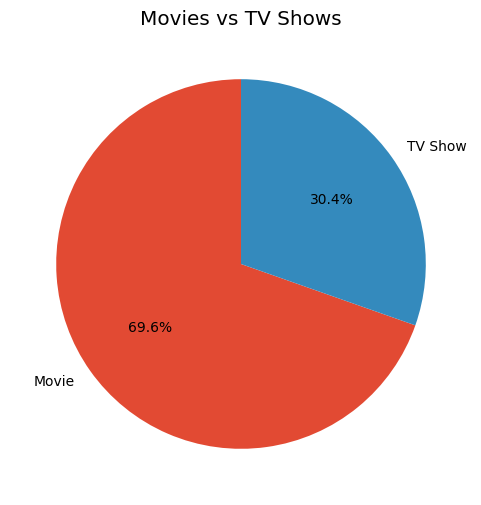

In [34]:
# DASHBOARD 1
# Movies vs TV Shows

type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Movies vs TV Shows")
plt.show()

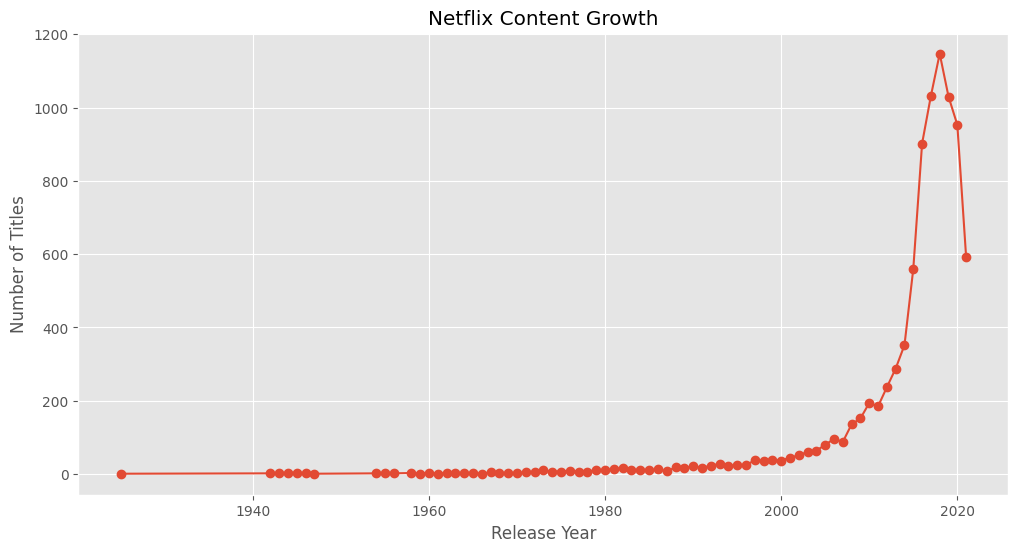

In [35]:
# DASHBOARD 2
# Content Growth Over Years

year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(
    year_counts.index,
    year_counts.values,
    marker='o'
)
plt.title("Netflix Content Growth")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

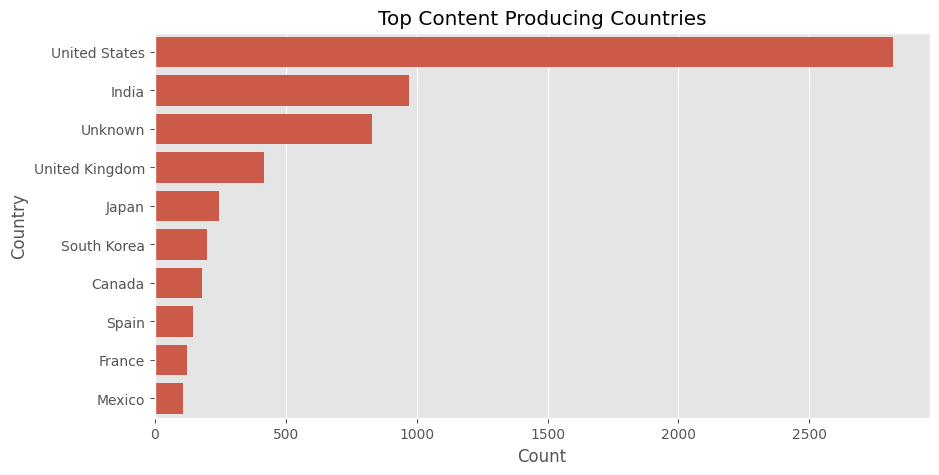

In [36]:
# DASHBOARD 3
# Top 10 Content Producing Countries

country_count = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=country_count.values,
    y=country_count.index
)
plt.title("Top Content Producing Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

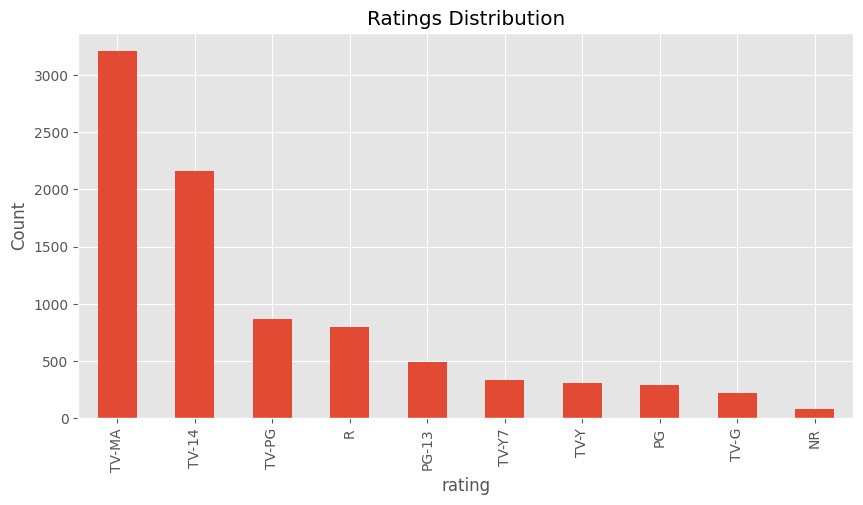

In [37]:
# DASHBOARD 4
# Ratings Distribution

plt.figure(figsize=(10,5))
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Ratings Distribution")
plt.ylabel("Count")
plt.show()

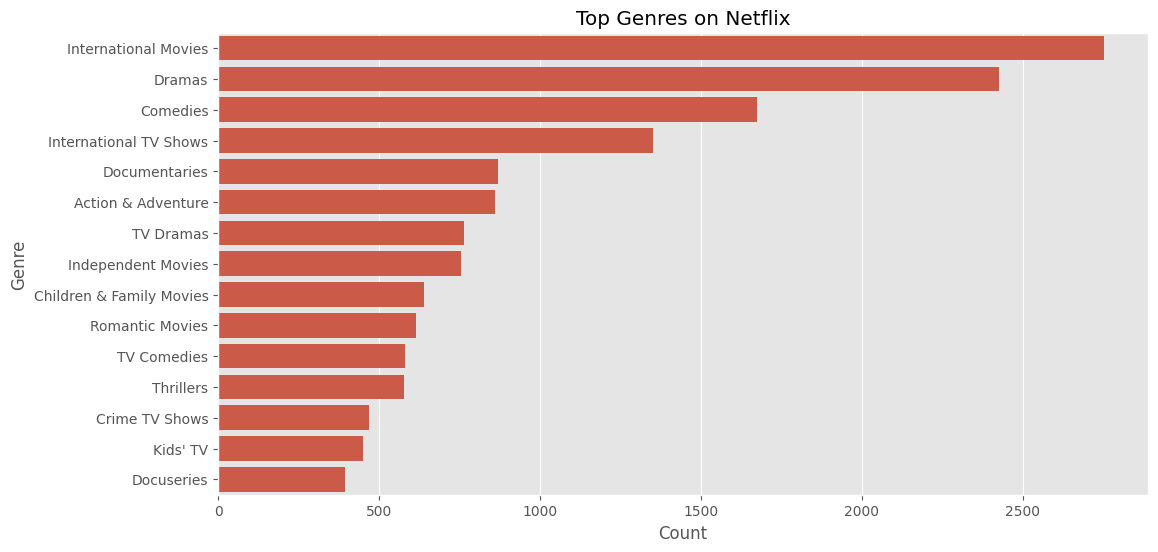

In [38]:
# DASHBOARD 5
# Genre Analysis

genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)
plt.title("Top Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [39]:
# DASHBOARD 6
# Interactive Plotly Dashboard

fig = px.histogram(
    df,
    x="release_year",
    color="type",
    title="Content by Year & Type",
    barmode="overlay"
)

fig.show()

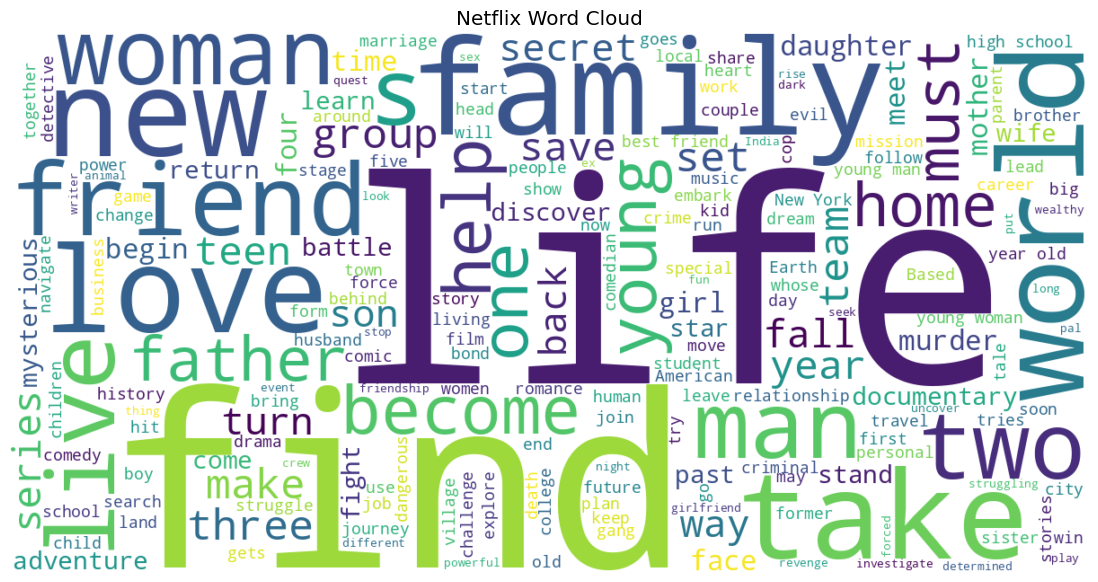

In [40]:
# DASHBOARD 7
# Netflix Word Cloud

text = " ".join(df['description'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Netflix Word Cloud")
plt.show()

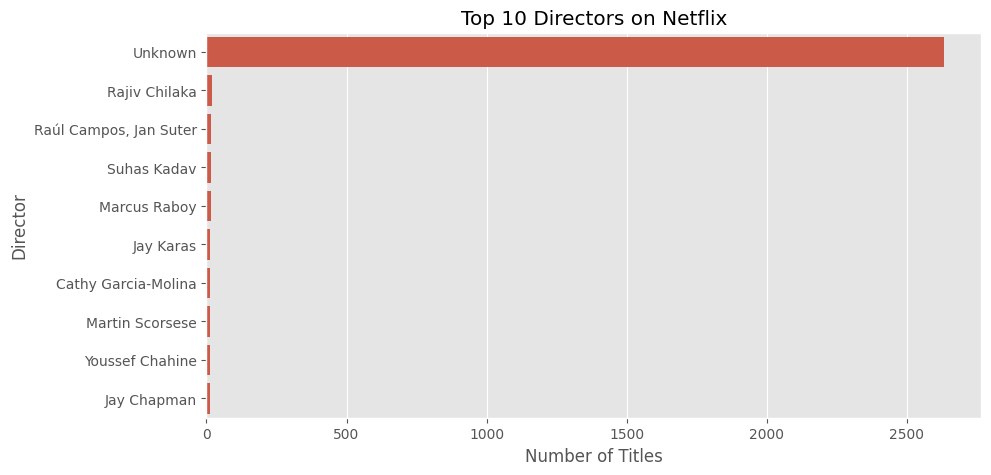

In [41]:
# ADVANCED TASK 1
# Most Prolific Directors

top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

In [42]:
# ADVANCED TASK 2
# Recommendation System

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['description'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def recommend(title, n=5):

    if title not in indices:
        print("Title not found")
        return

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:n+1]

    movie_indices = [i[0] for i in sim_scores]

    return df['title'].iloc[movie_indices]

# Example
print("Recommendations:")
print(recommend("Narcos"))


Recommendations:
7463                          Miss Dynamite
6673                            El Cartel 2
2921                         Narcos: Mexico
4750                               El Chapo
310     Cocaine Cowboys: The Kings of Miami
Name: title, dtype: object


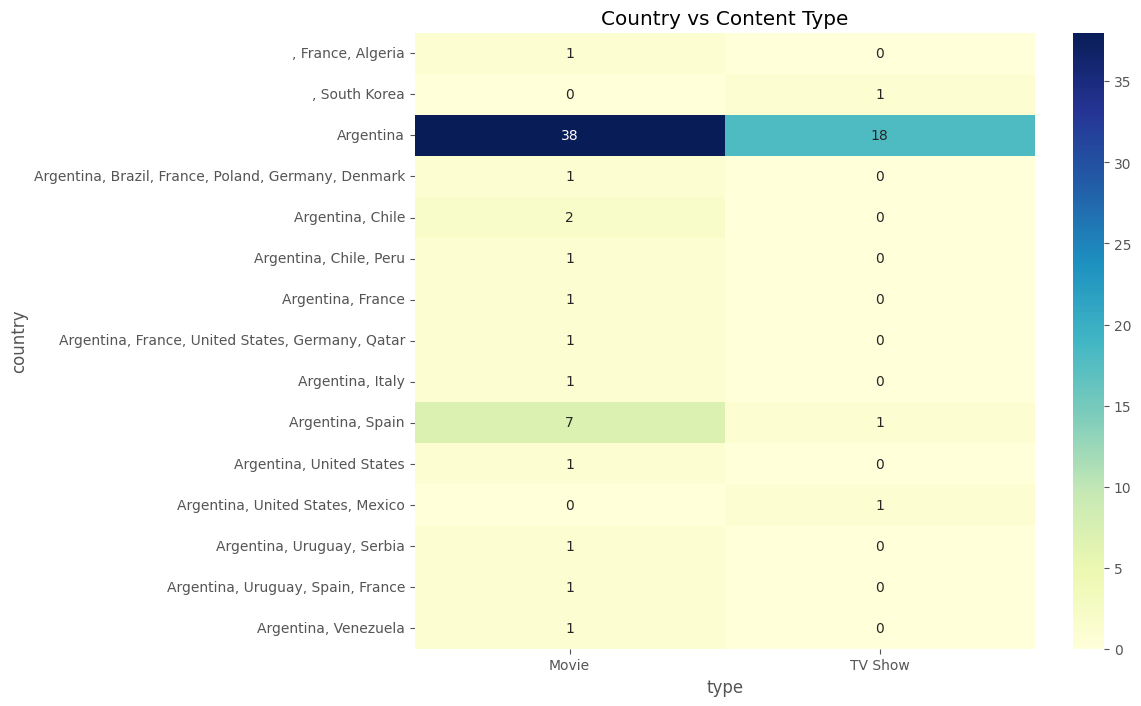

In [43]:
# ADVANCED TASK 3
# Country vs Type Heatmap

heatmap_data = pd.crosstab(
    df['country'],
    df['type']
).head(15)

plt.figure(figsize=(10,8))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Country vs Content Type")
plt.show()

In [44]:
# SUMMARY STATISTICS

print("\nTotal Titles:", len(df))
print("Movies:", len(df[df['type']=='Movie']))
print("TV Shows:", len(df[df['type']=='TV Show']))
print("Countries:", df['country'].nunique())
print("Genres:", genres.nunique())


Total Titles: 8807
Movies: 6131
TV Shows: 2676
Countries: 749
Genres: 42
